In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\Tafzeel\\Downloads\\doston.csv")
df.head()

,Comp. pres.,Green density,Class
0,335,6.497705,1
1,335,6.974476,1
2,335,7.254545,1
3,335,6.946334,1
4,335,6.717047,1


In [3]:
X = df.iloc[:, :-1].values
print(X)

[[335.           6.49770535]
 [335.           6.9744762 ]
 [335.           7.254545  ]
 [335.           6.94633422]
 [335.           6.71704702]
 [335.           7.07300111]
 [335.           7.25358965]
 [335.           7.19640909]
 [335.           7.4941551 ]
 [335.           7.30086002]
 [335.           7.26201099]
 [335.           7.5181875 ]
 [335.           6.87567111]
 [335.           7.05339789]
 [335.           6.8655    ]
 [335.           6.69753333]
 [335.           7.06285333]
 [335.           7.19952447]
 [335.           7.27980215]
 [335.           7.35034667]
 [335.           7.18446154]
 [335.           7.3225    ]
 [335.           7.36824706]
 [335.           7.41437349]
 [150.           6.25      ]
 [300.           6.85      ]
 [450.           7.38      ]
 [600.           7.67      ]
 [150.           5.3       ]
 [600.           6.76      ]
 [150.           5.99      ]
 [600.           7.49      ]
 [150.           5.27      ]
 [600.           6.92      ]
 [150.        

In [40]:
y = df.iloc[:, -1].values
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1
 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0
 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 0]


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 10)

In [52]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators = 200, criterion = 'entropy', random_state = 0)
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=0)

In [53]:
y_pred=rf.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
      dtype=int64)

In [54]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_pred,y_test)
cm

array([[18,  1],
       [ 6, 38]], dtype=int64)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


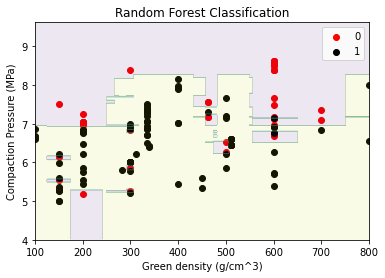

<Figure size 432x288 with 0 Axes>

In [56]:
x_set,y_set=X_train,y_train

plt.scatter(x_set[y_set == 0,0],x_set[y_set == 0,1],label=0,color='r')
plt.scatter(x_set[y_set == 1,0],x_set[y_set == 1,1],label=1,color='k')

x1,x2=np.meshgrid(np.arange(start=x_set[:,0].min()-1,stop=x_set[:,0].max()+1,step=0.02),
                  np.arange(start=x_set[:,1].min()-1,stop=x_set[:,1].max()+1,step=0.02))

z =rf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)

print(z)

plt.contourf(x1,x2,z,alpha=0.1)
plt.title('Random Forest Classification')
plt.xlabel('Green density (g/cm^3)')
plt.ylabel('Compaction Pressure (MPa)')
plt.legend()
plt.show()
plt.savefig('gc.png',dpi=900)